In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [ ]:
image = cv2.imread('7.png', cv2.IMREAD_GRAYSCALE)

array([[156, 159, 158, ..., 151, 152, 152],
       [160, 154, 157, ..., 154, 155, 153],
       [156, 159, 158, ..., 151, 152, 152],
       ...,
       [114, 132, 123, ..., 135, 137, 114],
       [121, 126, 130, ..., 133, 130, 113],
       [121, 126, 130, ..., 133, 130, 113]], dtype=uint8)
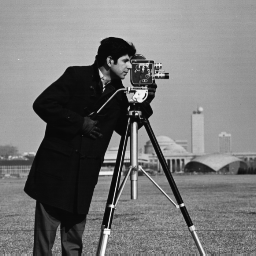

In [ ]:
image

 1. Load the Image with Salt and Pepper and Gaussian Noise with Different Intensities

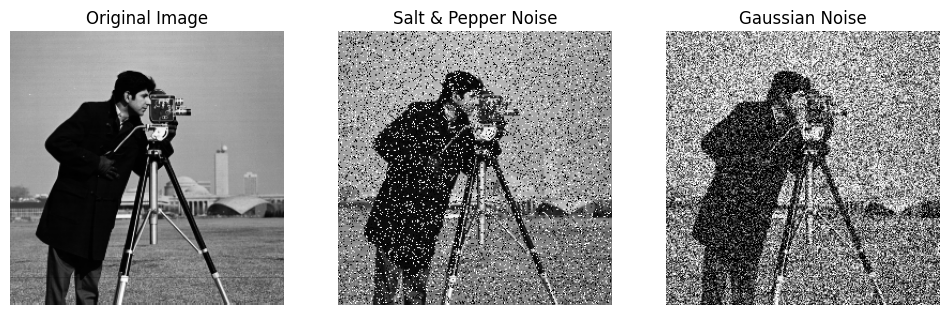

In [ ]:
# Function to add Salt and Pepper Noise
def salt_and_pepper(image, salt_prob, pepper_prob):
    noisy_image = image.copy()
    total_pixels = image.size

    # Salt noise (white pixels)
    num_salt = int(salt_prob * total_pixels)
    salt_coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy_image[salt_coords[0], salt_coords[1]] = 255  # white pixels

    # Pepper noise (black pixels)
    num_pepper = int(pepper_prob * total_pixels)
    pepper_coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy_image[pepper_coords[0], pepper_coords[1]] = 0  # black pixels

    return noisy_image

# Function to add Gaussian Noise
def gaussian_noise(image, mean=0, var=0.01):
    sigma = var ** 0.5
    gaussian = np.random.normal(mean, sigma, image.shape)
    noisy_image = np.clip(image + gaussian * 255, 0, 255).astype(np.uint8)
    return noisy_image

# Add Salt and Pepper Noise (10% salt, 10% pepper)
salt_pepper_image = salt_and_pepper(image, salt_prob=0.1, pepper_prob=0.1)

# Add Gaussian Noise (mean=0, variance=0.1)
gaussian_image = gaussian_noise(image, mean=0, var=0.1)

# Plot the original and noisy images
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(salt_pepper_image, cmap='gray')
plt.title("Salt & Pepper Noise")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gaussian_image, cmap='gray')
plt.title("Gaussian Noise")
plt.axis('off')

plt.show()

Salt and Pepper Noise is introduced by randomly setting a percentage of pixels to 0 (pepper) and 255 (salt).

Gaussian Noise is added using a Gaussian distribution with a mean of 0 and a variance (which controls the intensity).

2. Apply Alpha-Trimmed Filter to Reduce Salt and Pepper and Gaussian Noise

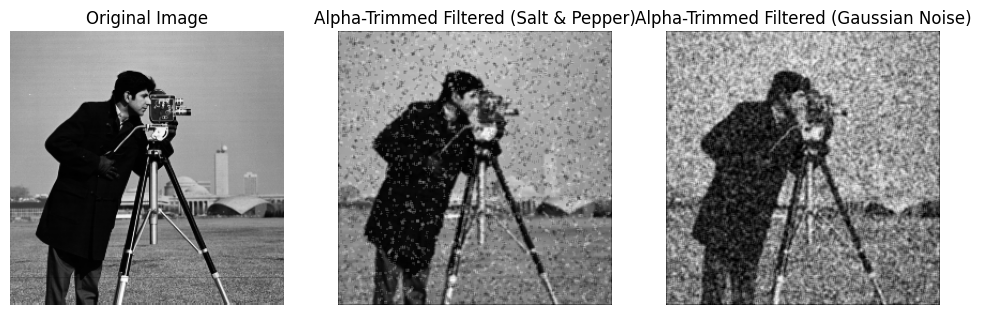

In [ ]:
def alpha_trimmed_filter(image, size, alpha):
    """
    Alpha-trimmed filter that removes 'alpha' smallest and largest pixel values
    from the neighborhood of each pixel.

    :param image: Noisy image
    :param size: Kernel size (e.g., 3, 5, 7)
    :param alpha: Number of extreme values to remove from the kernel
    :return: Filtered image
    """
    k = size // 2  # Define the radius of the kernel
    output_image = image.copy()
    padded_image = np.pad(image, ((k, k), (k, k)), mode='constant', constant_values=0)

    for i in range(k, padded_image.shape[0] - k):
        for j in range(k, padded_image.shape[1] - k):
            # Extract the neighborhood
            region = padded_image[i - k:i + k + 1, j - k:j + k + 1]
            sorted_region = np.sort(region.flatten())

            # Trim the extremes
            trimmed_region = sorted_region[alpha:len(sorted_region) - alpha]

            # Take the mean of the remaining values
            output_image[i - k, j - k] = np.mean(trimmed_region)

    return output_image

# Apply the Alpha-trimmed filter to both noisy images
alpha_trimmed_salt_pepper = alpha_trimmed_filter(salt_pepper_image, size=3, alpha=1)
alpha_trimmed_gaussian = alpha_trimmed_filter(gaussian_image, size=3, alpha=1)

# Plot the results
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(alpha_trimmed_salt_pepper, cmap='gray')
plt.title("Alpha-Trimmed Filtered (Salt & Pepper)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(alpha_trimmed_gaussian, cmap='gray')
plt.title("Alpha-Trimmed Filtered (Gaussian Noise)")
plt.axis('off')

plt.show()

An Alpha-trimmed filter is a non-linear filter that works by removing extreme pixel values (outliers) from the neighborhood of each pixel, usually based on a predefined number of pixels (alpha value).

The Alpha-trimmed filter works by sorting the pixel values in a neighborhood, removing the smallest and largest alpha percentage of them, and then averaging the remaining values.

3. Apply Adaptive Local Noise Reduction Filters

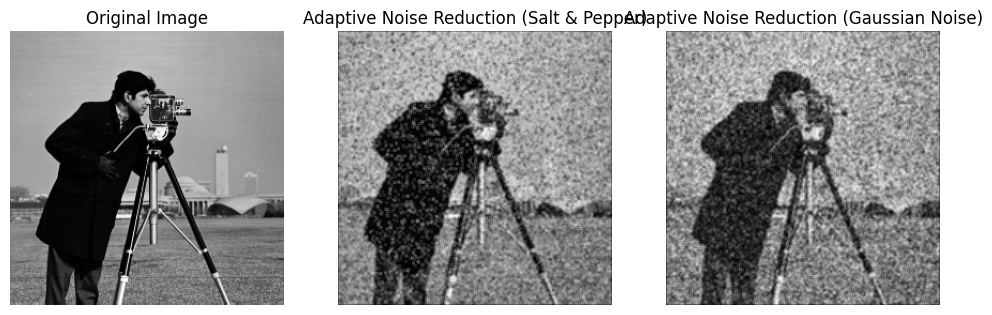

In [ ]:
def adaptive_local_noise_reduction(image, kernel_size=3, sigma_square=0.01):
    k = kernel_size // 2  # Kernel radius
    output_image = np.copy(image)
    padded_image = np.pad(image, ((k, k), (k, k)), mode='constant', constant_values=0)

    for i in range(k, padded_image.shape[0] - k):
        for j in range(k, padded_image.shape[1] - k):
            # Extract the local region
            region = padded_image[i - k:i + k + 1, j - k:j + k + 1]

            # Compute local mean and variance
            local_mean = np.mean(region)
            local_var = np.var(region)

            # Apply adaptive filter formula
            if local_var > sigma_square:
                output_image[i - k, j - k] = local_mean

    return output_image

# Apply Adaptive Local Noise Reduction to noisy images
adaptive_salt_pepper = adaptive_local_noise_reduction(salt_pepper_image, kernel_size=3, sigma_square=0.01)
adaptive_gaussian = adaptive_local_noise_reduction(gaussian_image, kernel_size=3, sigma_square=0.01)

# Plot the results
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(adaptive_salt_pepper, cmap='gray')
plt.title("Adaptive Noise Reduction (Salt & Pepper)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(adaptive_gaussian, cmap='gray')
plt.title("Adaptive Noise Reduction (Gaussian Noise)")
plt.axis('off')

plt.show()

The adaptive noise reduction filter uses local variance to decide how much smoothing is needed. If the variance is high (indicating noise), it smooths the pixel.

4. Implement Adaptive Median Filter

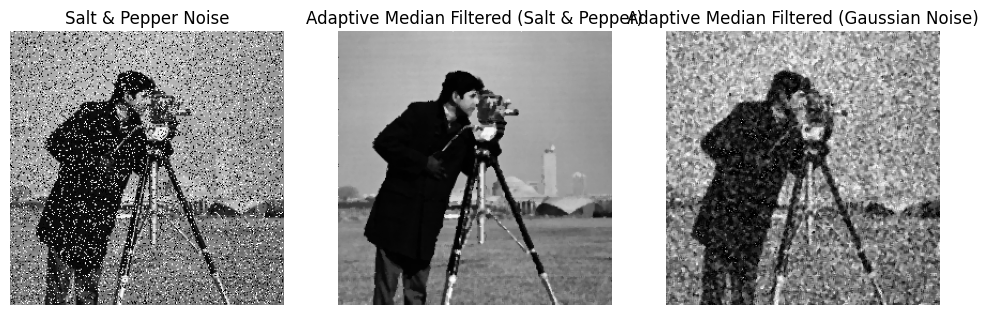

In [ ]:
def adaptive_median_filter(image, max_window_size=7):
    output_image = np.copy(image)
    rows, cols = image.shape

    for i in range(rows):
        for j in range(cols):
            window_size = 3
            while window_size <= max_window_size:
                k = window_size // 2
                # Ensure window stays within image bounds
                window = image[max(0, i - k):min(rows, i + k + 1),
                              max(0, j - k):min(cols, j + k + 1)]

                # Check if window is empty
                if window.size == 0:
                    break

                median = np.median(window)
                min_val = np.min(window)
                max_val = np.max(window)

                # Check if the pixel is noisy
                if min_val < median < max_val:
                    output_image[i, j] = median
                    break
                else:
                    window_size += 2

    return output_image

# Apply Adaptive Median Filter to noisy images
adaptive_median_salt_pepper = adaptive_median_filter(salt_pepper_image, max_window_size=7)
adaptive_median_gaussian = adaptive_median_filter(gaussian_image, max_window_size=7)

# Plot the results
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(salt_pepper_image, cmap='gray')
plt.title("Salt & Pepper Noise")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(adaptive_median_salt_pepper, cmap='gray')
plt.title("Adaptive Median Filtered (Salt & Pepper)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(adaptive_median_gaussian, cmap='gray')
plt.title("Adaptive Median Filtered (Gaussian Noise)")
plt.axis('off')

plt.show()

The Adaptive Median Filter is a non-linear filter that adjusts its window size based on the local noise level. If a pixel is corrupted by noise, the filter increases the window size to include more neighboring pixels, making it more effective in removing noise.

1. Noise addition: We added both salt-and-pepper and Gaussian noise to the image.

2. Alpha-trimmed filter: Reduced noise by removing extreme pixel values in the local neighborhood.

3. Adaptive Local Noise Reduction Filter: Adjusted the smoothing based on local variance.

4. Adaptive Median Filter: Adjusted its window size depending on the local noise level to effectively remove noise.